<div style="
    background-color: #F3E9D2;
    padding: 30px;
    border-radius: 15px;
    border-left: 8px solid #16324F;
    text-align: center;
    margin-bottom: 20px;
">

<h1 style="
    color: #16324F;
    margin-bottom: 10px;
    font-size: 36px;
">
☕ Análisis Exploratorio de Datos (EDA)
</h1>

<h2 style="
    color: #16324F;
    margin: 5px 0;
">
Café Cereza
</h2>

<hr style="
    border: none;
    height: 2px;
    background-color: #16324F;
    width: 70%;
">

<p style="
    color: #16324F;
    font-size: 18px;
    margin-top: 15px;
">
<b>Etapa 5 — Analítica de Datos para Negocios Digitales</b>
</p>

</div>


## Integrantes del equipo

| Integrante | Matrícula |
|:-----------|:---------:|
| **Michelle De La Cruz Rosalino** | 230091 |
| **Jose de Jesus Hernandez Casiano** | 230535 |
| **Yuleni Gayosso Martines** | 230145 |


## Descripción

Este notebook corresponde a la **Etapa 5 del proyecto Café Cereza** y tiene como propósito realizar un **Análisis Exploratorio de Datos (EDA)** para conocer el comportamiento de la información relacionada con las ventas, productos, clientes, canales de venta, pedidos y reservaciones.

Para el desarrollo del análisis se utiliza como fuente principal el archivo **`dataset_ventas_limpio.csv`**, sobre el cual se aplican diferentes técnicas estadísticas y gráficas para identificar patrones, tendencias y resultados relevantes que puedan apoyar la toma de decisiones del negocio.



## Consideración importante sobre los datos

Cada fila del dataset representa una **línea de producto dentro de un pedido**, por lo que un mismo `id_pedido` puede aparecer varias veces cuando contiene diferentes productos.

Por esta razón, para analizar métricas a nivel de pedido como:

- **Ingresos**
- **Ticket promedio**
- **Cantidad de pedidos**
- **Tiempo de entrega**
- **Calificación del servicio**

se utiliza una tabla auxiliar denominada **`pedidos_df`**, que conserva un solo registro por `id_pedido`. Esto permite evitar duplicaciones y obtener resultados correctos.

Para los análisis relacionados con **productos, categorías y unidades vendidas**, se utiliza el dataset completo `df`, ya que cada fila representa correctamente el detalle de un producto vendido.



## Objetivos del notebook

1. **Revisar la calidad y cobertura de los datos**, verificando la cantidad de registros, pedidos, clientes y periodo disponible.

2. **Realizar un análisis univariado** para conocer la distribución y comportamiento individual de las principales variables.

3. **Realizar un análisis bivariado** para comparar y explorar relaciones entre dos variables.

4. **Realizar un análisis multivariado** para estudiar conjuntamente diferentes variables relacionadas con las ventas y el comportamiento de los clientes.

5. **Analizar las tendencias temporales** de los ingresos y pedidos por mes, día y hora.

6. **Generar visualizaciones** que permitan representar de manera clara los principales resultados obtenidos.

7. **Identificar hallazgos relevantes** que permitan responder las preguntas de negocio planteadas para Café Cereza y apoyar la toma de decisiones.


# Índice

#### 5.1 Análisis Exploratorio de Datos (EDA)
- 5.1 Carga y preparación de los datos
- 5.1.1 Carga de librerías y dataset
- 5.1.2 Preparación de variables
- 5.1.3 Creación de la tabla de pedidos únicos (`pedidos_df`)

#### 5.2 Análisis univariado
- 5.2.1 Medidas estadísticas descriptivas
- 5.2.2 Frecuencias y moda de variables categóricas
- 5.2.3 Ejemplo de tabla de frecuencias

##### Distribuciones de variables numéricas
- Gráfica 1. Distribución del ticket total por pedido
- Gráfica 2. Distribución del tiempo de entrega
- Gráfica 3. Distribución de calificaciones del servicio

#### 5.3 Análisis bivariado
- Gráfica 4. Unidades vendidas por categoría
- Gráfica 5. Top 10 productos más vendidos
- Gráfica 6. Ingresos por categoría
- Gráfica 7. Ticket promedio por canal de venta
- Gráfica 8. Número de pedidos por tipo de cliente
- Gráfica 9. Tiempo promedio de entrega por canal
- Gráfica 10. Reservaciones por estado

#### 5.4 Análisis multivariado
- Gráfica 11. Ventas mensuales por canal
- Gráfica 12. Unidades por categoría y canal

#### 5.5 Análisis temporal
- Gráfica 14. Tendencia mensual de ingresos
- Gráfica 15. Comparación mensual 2025 vs 2026
- Gráfica 16. Pedidos por hora del día
- Gráfica 17. Pedidos por día de la semana
- Gráfica 18. Participación mensual del canal web
- Gráfica 19. Pedidos antes y después del lanzamiento web

#### 5.6 Correlación entre variables numéricas

- 5.7 Hallazgos automáticos
- 5.7.1 Principales resultados obtenidos
- 5.7.2 Producto y categoría con mayor demanda
- 5.7.3 Canal con mayor ticket promedio
- 5.7.4 Día y hora de mayor demanda
- 5.7.5 Mes con mayores ingresos
- 5.7.6 Cancelaciones y no_show en reservaciones

#### 5.8 Relación entre preguntas de negocio y resultados
- 5.8.1 Días y horarios de mayor demanda
- 5.8.2 Productos con mayor demanda
- 5.8.3 Canal con mayor ticket promedio
- 5.8.4 Comportamiento de las cancelaciones
- 5.8.5 No asistencia en reservaciones
- 5.8.6 Evolución de la participación del canal web

#### 5.9 Observaciones metodológicas importantes
- Diferencia entre `df` y `pedidos_df`
- Tratamiento correcto de los ingresos
- Análisis de productos y categorías
- Limitaciones de las variables disponibles
- Cobertura temporal de 2026
- Correlación y causalidad

#### 5.10 Conclusiones del Análisis Exploratorio de Datos

## 1. Carga de librerías y dataset
En esta primera etapa se realizó la preparación del entorno de trabajo mediante la importación de las librerías Pandas, NumPy, Matplotlib y Pathlib, necesarias para la manipulación, análisis y posterior visualización de los datos. Posteriormente, se cargó el archivo dataset_ventas_limpio.csv, que contiene la información que será utilizada para desarrollar el análisis exploratorio de Café Cereza.

La carga se realizó correctamente y se verificó la existencia del archivo antes de intentar leerlo, permitiendo detectar posibles errores relacionados con su ubicación. Como resultado, se obtuvo un dataset compuesto por 3,754 registros y 31 columnas, los cuales constituyen la base de información para los análisis y gráficas que se desarrollarán en los siguientes apartados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Coloca dataset_ventas_limpio.csv en la misma carpeta que este notebook.
ARCHIVO = Path('dataset_ventas_limpio.csv')

if not ARCHIVO.exists():
    raise FileNotFoundError(
        "No se encontró 'dataset_ventas_limpio.csv'. "
        "Coloca el archivo en la misma carpeta que este notebook "
        "o cambia la ruta en la variable ARCHIVO."
    )

df = pd.read_csv(ARCHIVO)

print(f'Dataset cargado correctamente: {ARCHIVO}')
print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')


Dataset cargado correctamente: dataset_ventas_limpio.csv
Filas: 3,754
Columnas: 31


## 2. Preparación de variables

En esta etapa se prepararon las variables de fecha y hora para facilitar el análisis temporal de los datos. También se crearon variables como año, mes, día de la semana y hora del pedido. Finalmente, se generó una tabla con un registro por pedido, obteniendo **3,754 filas de detalle, 1,500 pedidos únicos y 250 clientes únicos.**


In [2]:
# Conversión de fechas
df['fecha_pedido'] = pd.to_datetime(df['fecha_pedido'], errors='coerce')
df['fecha_registro_cliente'] = pd.to_datetime(df['fecha_registro_cliente'], errors='coerce')
df['fecha_reservacion'] = pd.to_datetime(df['fecha_reservacion'], errors='coerce')

# Conversión de hora
df['hora_pedido_dt'] = pd.to_datetime(df['hora_pedido'], format='%H:%M:%S', errors='coerce')
df['hora'] = df['hora_pedido_dt'].dt.hour

# Variables temporales
df['anio'] = df['fecha_pedido'].dt.year
df['mes_num'] = df['fecha_pedido'].dt.month
df['mes'] = df['fecha_pedido'].dt.month_name()
df['periodo_mes'] = df['fecha_pedido'].dt.to_period('M').astype(str)

dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_es = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}
df['dia_semana_en'] = df['fecha_pedido'].dt.day_name()
df['dia_semana'] = df['dia_semana_en'].map(dias_es)

# Tabla de pedidos: una fila por id_pedido
pedidos_df = (
    df.sort_values(['id_pedido', 'id_venta'])
      .drop_duplicates(subset='id_pedido', keep='first')
      .copy()
)

pedidos_df['anio'] = pedidos_df['fecha_pedido'].dt.year
pedidos_df['mes_num'] = pedidos_df['fecha_pedido'].dt.month
pedidos_df['mes'] = pedidos_df['fecha_pedido'].dt.month_name()
pedidos_df['periodo_mes'] = pedidos_df['fecha_pedido'].dt.to_period('M').astype(str)
pedidos_df['hora'] = pedidos_df['hora_pedido_dt'].dt.hour
pedidos_df['dia_semana_en'] = pedidos_df['fecha_pedido'].dt.day_name()
pedidos_df['dia_semana'] = pedidos_df['dia_semana_en'].map(dias_es)

print('Filas de detalle:', len(df))
print('Pedidos únicos:', pedidos_df['id_pedido'].nunique())
print('Clientes únicos:', df['id_cliente'].nunique())


Filas de detalle: 3754
Pedidos únicos: 1500
Clientes únicos: 250


# 5.1 Análisis de calidad

Se evaluó la calidad general del dataset para comprobar su consistencia e integridad. Los resultados muestran 3,754 registros, 1,500 pedidos únicos y 250 clientes, sin duplicados exactos ni identificadores de venta repetidos. Además, los datos abarcan desde el 3 de enero de 2025 hasta el 19 de agosto de 2026, proporcionando una cobertura temporal amplia para el análisis.


In [3]:
# Resumen general
resumen = pd.DataFrame({
    'Métrica': [
        'Filas de detalle',
        'Columnas',
        'Pedidos únicos',
        'Clientes únicos',
        'Duplicados exactos',
        'ID venta duplicados',
        'Fecha mínima',
        'Fecha máxima'
    ],
    'Resultado': [
        len(df),
        df.shape[1],
        df['id_pedido'].nunique(),
        df['id_cliente'].nunique(),
        df.duplicated().sum(),
        df['id_venta'].duplicated().sum(),
        df['fecha_pedido'].min(),
        df['fecha_pedido'].max()
    ]
})

resumen


,Métrica,Resultado
0,Filas de detalle,3754
1,Columnas,39
2,Pedidos únicos,1500
3,Clientes únicos,250
4,Duplicados exactos,0
5,ID venta duplicados,0
6,Fecha mínima,2025-01-03 00:00:00
7,Fecha máxima,2026-08-19 00:00:00


In [4]:
# Valores nulos por columna
nulos = pd.DataFrame({
    'Nulos': df.isna().sum(),
    'Porcentaje_nulos': (df.isna().mean() * 100).round(2)
})

nulos[nulos['Nulos'] > 0].sort_values('Porcentaje_nulos', ascending=False)


,Nulos,Porcentaje_nulos
fecha_reservacion,2843,75.73
estado_reservacion,2843,75.73
id_mesa,1822,48.53
ubicacion_mesa,1822,48.53
tipo_mesa,1822,48.53
calificacion_servicio,1147,30.55
tiempo_entrega_min,592,15.77


### Nota sobre valores nulos

Algunas columnas relacionadas con mesas y reservaciones pueden contener valores nulos de forma legítima cuando un pedido no tiene reservación. Por ello, un valor nulo **no debe interpretarse automáticamente como error**.


In [7]:
# Detección simple de atípicos con IQR para variables numéricas
variables_numericas = [
    'cantidad',
    'precio_unitario',
    'subtotal_linea',
    'subtotal_pedido',
    'impuestos',
    'total_pedido',
    'tiempo_entrega_min',
    'calificacion_servicio'
]

resultados_outliers = []

for col in variables_numericas:
    serie = df[col].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    cantidad_outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()

    resultados_outliers.append({
        'Variable': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'Límite inferior': round(limite_inf, 2),
        'Límite superior': round(limite_sup, 2),
        'Atípicos IQR': int(cantidad_outliers)
    })

pd.DataFrame(resultados_outliers)


,Variable,Q1,Q3,Límite inferior,Límite superior,Atípicos IQR
0,cantidad,1.00,3.00,-2.00,6.00,0
1,precio_unitario,33.63,53.27,4.17,82.72,156
2,subtotal_linea,51.74,117.05,-46.22,215.01,94
3,subtotal_pedido,182.08,350.19,-70.09,602.36,31
4,impuestos,29.13,56.03,-11.21,96.38,31
5,total_pedido,211.21,406.22,-81.31,698.74,31
6,tiempo_entrega_min,17.00,37.00,-13.00,67.00,0
7,calificacion_servicio,3.00,5.00,0.00,8.00,0


# 5.2 Análisis univariado

En esta sección se analiza cada variable de manera individual.


### 5.2.1 Medidas estadísticas descriptivas

En esta sección se calculan diferentes medidas estadísticas que permiten resumir y comprender el comportamiento de las variables numéricas del dataset.

- **Media:** Representa el promedio de los valores. Permite conocer, por ejemplo, el monto promedio de los pedidos, el tiempo promedio de entrega o la calificación promedio del servicio.

- **Mediana:** Indica el valor central de los datos después de ordenarlos. Es útil para conocer un valor representativo cuando existen valores muy altos o muy bajos que pueden afectar el promedio.

- **Moda:** Corresponde al valor que aparece con mayor frecuencia. Permite identificar, por ejemplo, cantidades o calificaciones que se repiten con mayor frecuencia.

- **Mínimo:** Indica el valor más pequeño registrado en cada variable, permitiendo conocer el límite inferior de los datos analizados.

- **Máximo:** Representa el valor más alto registrado y permite identificar el límite superior alcanzado por cada variable.

- **Varianza:** Mide qué tanto se dispersan los valores respecto a su media. Una varianza mayor indica que existen diferencias más amplias entre los datos.

- **Desviación estándar:** Indica cuánto suelen alejarse los valores de su promedio y facilita conocer si los datos presentan poca o mucha variación.

- **Percentiles:** Dividen los datos ordenados en diferentes partes. Permiten conocer cómo se distribuyen los valores e identificar qué porcentaje de los registros se encuentra por debajo de determinados niveles.

> **Nota:** Para las variables relacionadas con cada pedido, como `total_pedido`, `tiempo_entrega_min` y `calificacion_servicio`, se utiliza `pedidos_df`, ya que contiene una sola fila por pedido. Para las variables relacionadas con los productos, como `cantidad`, `precio_unitario` y `subtotal_linea`, se utiliza `df`, que conserva todas las líneas de detalle de cada pedido.

In [8]:
# Función para obtener las medidas estadísticas solicitadas
def medidas_descriptivas(serie):
    serie = pd.to_numeric(serie, errors='coerce').dropna()
    moda = serie.mode()

    return pd.Series({
        'Media': serie.mean(),
        'Mediana': serie.median(),
        'Moda': moda.iloc[0] if not moda.empty else np.nan,
        'Mínimo': serie.min(),
        'Máximo': serie.max(),
        'Varianza': serie.var(),
        'Desviación estándar': serie.std(),
        'Percentil 25': serie.quantile(0.25),
        'Percentil 50': serie.quantile(0.50),
        'Percentil 75': serie.quantile(0.75),
        'Percentil 90': serie.quantile(0.90)
    })

# Variables que pertenecen a cada línea de producto
variables_linea = ['cantidad', 'precio_unitario', 'subtotal_linea']

# Variables que deben analizarse una sola vez por pedido
variables_pedido = ['subtotal_pedido', 'impuestos', 'total_pedido',
                    'tiempo_entrega_min', 'calificacion_servicio']

estadisticas_linea = pd.DataFrame({
    col: medidas_descriptivas(df[col])
    for col in variables_linea
}).T.round(2)

estadisticas_pedido = pd.DataFrame({
    col: medidas_descriptivas(pedidos_df[col])
    for col in variables_pedido
}).T.round(2)

print('MEDIDAS DESCRIPTIVAS — VARIABLES POR LÍNEA DE PRODUCTO')
display(estadisticas_linea)

print('\nMEDIDAS DESCRIPTIVAS — VARIABLES POR PEDIDO')
display(estadisticas_pedido)


MEDIDAS DESCRIPTIVAS — VARIABLES POR LÍNEA DE PRODUCTO


,Media,Mediana,Moda,Mínimo,Máximo,Varianza,Desviación estándar,Percentil 25,Percentil 50,Percentil 75,Percentil 90
cantidad,2.01,2.00,2.00,1.00,3.00,0.66,0.81,1.00,2.00,3.00,3.00
precio_unitario,45.20,42.31,35.96,20.03,94.99,247.56,15.73,33.63,42.31,53.27,64.94
subtotal_linea,90.85,81.82,39.64,20.07,284.97,2505.84,50.06,51.74,81.82,117.05,160.61



MEDIDAS DESCRIPTIVAS — VARIABLES POR PEDIDO


,Media,Mediana,Moda,Mínimo,Máximo,Varianza,Desviación estándar,Percentil 25,Percentil 50,Percentil 75,Percentil 90
subtotal_pedido,227.37,215.38,154.90,21.40,671.39,16447.02,128.25,122.26,215.38,310.0,398.28
impuestos,36.38,34.46,4.64,3.42,107.42,421.05,20.52,19.56,34.46,49.6,63.72
total_pedido,263.75,249.84,179.68,24.82,778.81,22131.13,148.77,141.82,249.84,359.6,462.00
tiempo_entrega_min,26.60,27.00,9.00,8.00,45.00,123.97,11.13,17.00,27.00,37.0,42.00
calificacion_servicio,4.08,4.00,5.00,1.00,5.00,1.18,1.09,4.00,4.00,5.0,5.00


### Cómo interpretar estas medidas

Al redactar el análisis, compara especialmente **media y mediana**. Si son muy diferentes, puede existir una distribución asimétrica o valores extremos. La **moda** permite identificar el valor más frecuente. La **varianza** y la **desviación estándar** ayudan a determinar qué tan dispersos son los datos. Los **percentiles 25, 50, 75 y 90** permiten observar cómo se distribuyen los valores sin depender únicamente del promedio.


### 5.2.2 Frecuencias y moda de variables categóricas

En este análisis se identificaron las categorías que aparecen con mayor frecuencia en las principales variables categóricas del dataset. Los resultados muestran que predominan la categoría **Repostería**, el producto **Frappé de café**, la **Página web** como canal de venta, los **clientes frecuentes**, los pedidos **en el lugar**, el **pago en línea** y el estado **entregado**. Esto permite reconocer las características y preferencias más frecuentes dentro de los registros de Café Cereza.


In [35]:
variables_categoricas = [
    'categoria_producto',
    'producto',
    'canal_venta',
    'tipo_cliente',
    'tipo_pedido',
    'metodo_pago',
    'estado_pedido'
]

resumen_categoricas = []

for col in variables_categoricas:
    conteo = df[col].value_counts(dropna=False)
    moda = df[col].mode()
    resumen_categoricas.append({
        'Variable': col,
        'Categorías distintas': df[col].nunique(dropna=True),
        'Moda': moda.iloc[0] if not moda.empty else 'Sin moda',
        'Frecuencia de la moda': int(conteo.iloc[0]) if len(conteo) else 0,
        'Porcentaje de la moda': round((conteo.iloc[0] / len(df)) * 100, 2) if len(conteo) else 0
    })

resumen_categoricas = pd.DataFrame(resumen_categoricas)
display(resumen_categoricas)


,Variable,Categorías distintas,Moda,Frecuencia de la moda,Porcentaje de la moda
0,categoria_producto,6,Repostería,652,17.37
1,producto,29,Frappé de café,179,4.77
2,canal_venta,3,Página web,2120,56.47
3,tipo_cliente,4,Frecuente,2319,61.77
4,tipo_pedido,2,en el lugar,1932,51.47
5,metodo_pago,4,pago en línea,1838,48.96
6,estado_pedido,4,entregado,2607,69.45


### 5.2.3 Ejemplo de tabla de frecuencias

La tabla muestra la distribución de las **categorías de producto** mediante su frecuencia y porcentaje. **Repostería** presenta la mayor frecuencia con **652 registros (17.37 %)**, seguida de **Café caliente (17.13 %)** y **Café frío (17.02 %)**. En general, los porcentajes son similares entre las seis categorías, lo que indica una distribución relativamente equilibrada de los productos registrados.


In [11]:
frecuencia_categoria = df['categoria_producto'].value_counts().to_frame('Frecuencia')
frecuencia_categoria['Porcentaje'] = (
    frecuencia_categoria['Frecuencia'] / frecuencia_categoria['Frecuencia'].sum() * 100
).round(2)

display(frecuencia_categoria)


,Frecuencia,Porcentaje
categoria_producto,,
Repostería,652,17.37
Café caliente,643,17.13
Café frío,639,17.02
Alimentos,630,16.78
Bebidas frías,596,15.88
Bebidas calientes,594,15.82


In [12]:
# Estadística descriptiva de variables numéricas
estadisticas = df[variables_numericas].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90]
).T

estadisticas['varianza'] = df[variables_numericas].var()
estadisticas['moda'] = [
    df[col].mode().iloc[0] if not df[col].mode().empty else np.nan
    for col in variables_numericas
]

estadisticas.round(2)


,count,mean,std,min,25%,50%,75%,90%,max,varianza,moda
cantidad,3754.0,2.01,0.81,1.00,1.00,2.00,3.00,3.00,3.00,0.66,2.00
precio_unitario,3754.0,45.20,15.73,20.03,33.63,42.31,53.27,64.94,94.99,247.56,35.96
subtotal_linea,3754.0,90.85,50.06,20.07,51.74,81.82,117.05,160.61,284.97,2505.84,39.64
subtotal_pedido,3754.0,271.68,124.89,21.40,182.08,269.91,350.19,436.60,671.39,15598.22,297.49
impuestos,3754.0,43.47,19.98,3.42,29.13,43.19,56.03,69.86,107.42,399.32,47.60
total_pedido,3754.0,315.14,144.88,24.82,211.21,313.10,406.22,506.46,778.81,20988.97,345.09
tiempo_entrega_min,3162.0,26.70,11.10,8.00,17.00,27.00,37.00,42.00,45.00,123.25,9.00
calificacion_servicio,2607.0,4.07,1.09,1.00,3.00,4.00,5.00,5.00,5.00,1.18,5.00


### Gráfica 1. Distribución del ticket total por pedido

La gráfica muestra que la mayoría de los pedidos se concentra en **tickets bajos y medios**, principalmente entre aproximadamente **100 y 400 MXN**, mientras que los pedidos con montos superiores a **500 MXN** son menos frecuentes. El ticket promedio es de **263.75 MXN** y la mediana de **249.84 MXN**, aunque existen pedidos que alcanzan hasta **778.81 MXN**. Esto indica que las compras de montos muy altos son poco comunes. Una posible explicación es que los clientes suelen realizar pedidos de pocos productos o de consumo individual. Con base en esto, Café Cereza podría implementar **combos, promociones o estrategias de venta adicional** para aumentar el valor promedio de los pedidos.


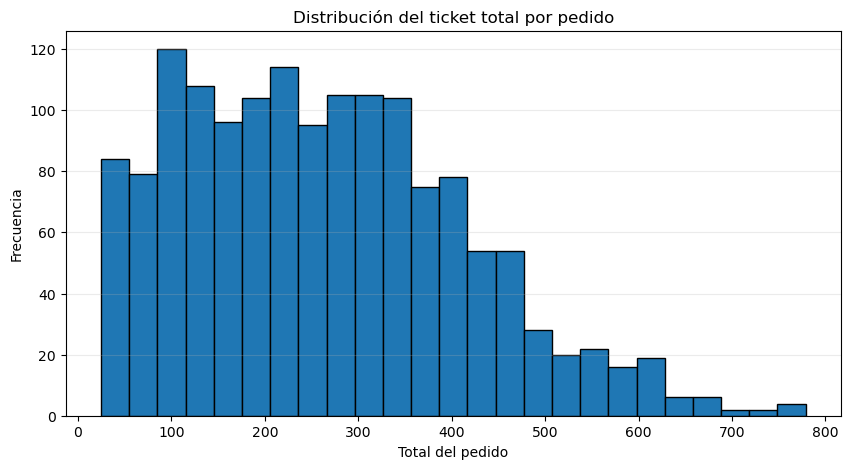

Media: 263.75
Mediana: 249.84
Moda: 179.68
Mínimo: 24.82
Máximo: 778.81


In [13]:
plt.figure(figsize=(10, 5))
plt.hist(pedidos_df['total_pedido'].dropna(), bins=25, edgecolor='black')
plt.title('Distribución del ticket total por pedido')
plt.xlabel('Total del pedido')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.25)
plt.show()

print('Media:', round(pedidos_df['total_pedido'].mean(), 2))
print('Mediana:', round(pedidos_df['total_pedido'].median(), 2))
print('Moda:', pedidos_df['total_pedido'].mode().iloc[0])
print('Mínimo:', pedidos_df['total_pedido'].min())
print('Máximo:', pedidos_df['total_pedido'].max())


## Gráfica 2. Distribución del tiempo de entrega



La gráfica muestra que los tiempos de entrega se distribuyen entre **8 y 45 minutos**, con un promedio de **26.60 minutos** y una mediana de **27 minutos**. Esto indica que los pedidos presentan tiempos de entrega variados, sin concentrarse únicamente en un intervalo específico. Una posible explicación podría estar relacionada con diferencias en la cantidad de productos, su preparación o la demanda en ciertos horarios. Con base en estos resultados, Café Cereza podría **identificar los pedidos con mayores tiempos de entrega y optimizar su proceso de preparación y atención** para reducir las esperas.

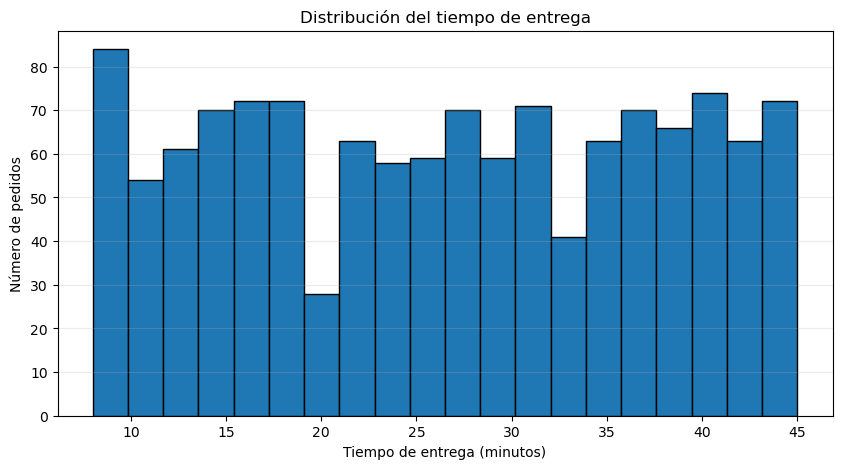

count    1270.00
mean       26.60
std        11.13
min         8.00
25%        17.00
50%        27.00
75%        37.00
max        45.00
Name: tiempo_entrega_min, dtype: float64

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(pedidos_df['tiempo_entrega_min'].dropna(), bins=20, edgecolor='black')
plt.title('Distribución del tiempo de entrega')
plt.xlabel('Tiempo de entrega (minutos)')
plt.ylabel('Número de pedidos')
plt.grid(axis='y', alpha=0.25)
plt.show()

pedidos_df['tiempo_entrega_min'].describe().round(2)


### Gráfica 3. Distribución de calificaciones del servicio

La gráfica muestra una clara concentración de calificaciones positivas, destacando la puntuación de **5 estrellas con 483 pedidos**, seguida de **4 estrellas con 307**. Esto indica una percepción favorable del servicio por parte de la mayoría de los clientes. Una posible explicación podría ser una buena atención y experiencia durante el proceso de compra. Con base en estos resultados, Café Cereza podría **mantener las prácticas que generan satisfacción e identificar las causas de las calificaciones bajas para mejorar el servicio**.


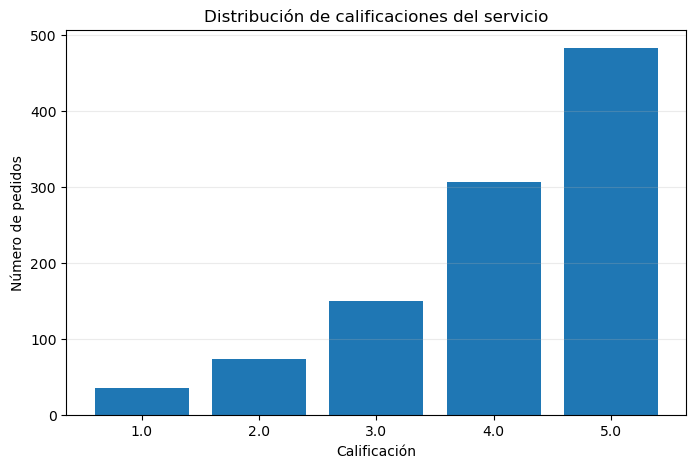

calificacion_servicio
1.0     35
2.0     74
3.0    150
4.0    307
5.0    483
Name: count, dtype: int64

In [15]:
calificaciones = (
    pedidos_df['calificacion_servicio']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.bar(calificaciones.index.astype(str), calificaciones.values)
plt.title('Distribución de calificaciones del servicio')
plt.xlabel('Calificación')
plt.ylabel('Número de pedidos')
plt.grid(axis='y', alpha=0.25)
plt.show()

calificaciones


# 5.3 Análisis bivariado

En esta sección se analiza la **relación entre dos variables** con el propósito de identificar posibles patrones o diferencias entre ellas. Este análisis permite comprender cómo variables como las **ventas, productos, clientes, canales o tiempos de entrega** pueden relacionarse entre sí y aportar información útil para la toma de decisiones en Café Cereza.



### Gráfica 4. Unidades vendidas por categoría

La gráfica muestra que **Repostería** es la categoría con mayor cantidad de unidades vendidas, con **1,321 unidades**, seguida de **Café caliente con 1,282** y **Alimentos con 1,271**. Aunque existen diferencias entre las categorías, las ventas se mantienen relativamente equilibradas. Una posible explicación es que los clientes presentan interés por distintos tipos de productos y no únicamente por una categoría. Con base en esto, Café Cereza podría **mantener un inventario equilibrado y reforzar promociones en las categorías con menor número de unidades vendidas**.


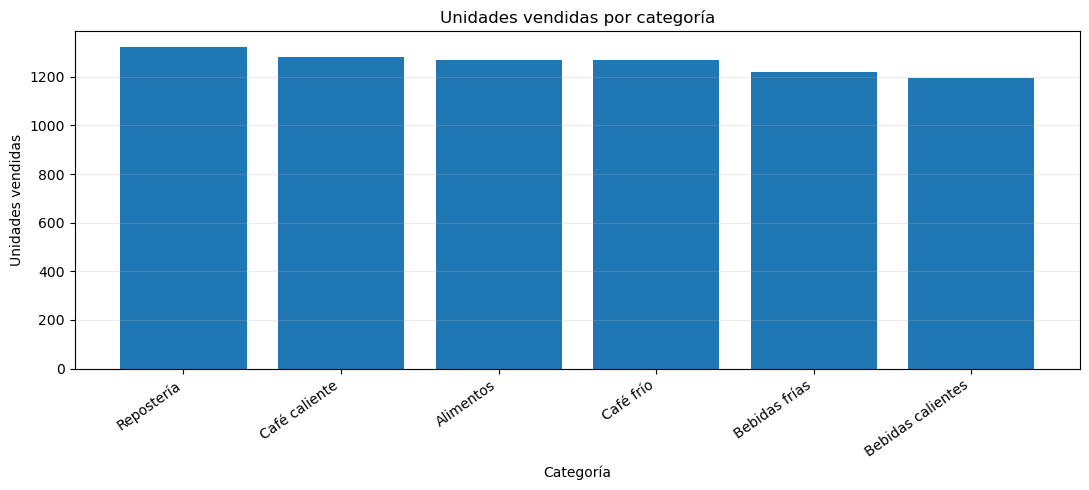

,unidades_vendidas
categoria_producto,
Repostería,1321
Café caliente,1282
Alimentos,1271
Café frío,1269
Bebidas frías,1220
Bebidas calientes,1194


In [16]:
ventas_categoria = (
    df.groupby('categoria_producto')['cantidad']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(11, 5))
plt.bar(ventas_categoria.index, ventas_categoria.values)
plt.title('Unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

ventas_categoria.to_frame('unidades_vendidas')


## Gráfica 5. Top 10 productos más vendidos

La gráfica muestra que el **Frappé de café** es el producto más vendido con **352 unidades**, seguido del **Chocolate caliente con 346** y el **Sandwich club con 345**. Esto refleja que las preferencias de los clientes se distribuyen entre bebidas y alimentos, con diferencias relativamente pequeñas entre los productos del top 10. Una posible explicación es la popularidad y demanda constante de estos productos. Con base en estos resultados, Café Cereza podría **asegurar su disponibilidad en inventario y utilizarlos en promociones o combos con productos de menor demanda**.


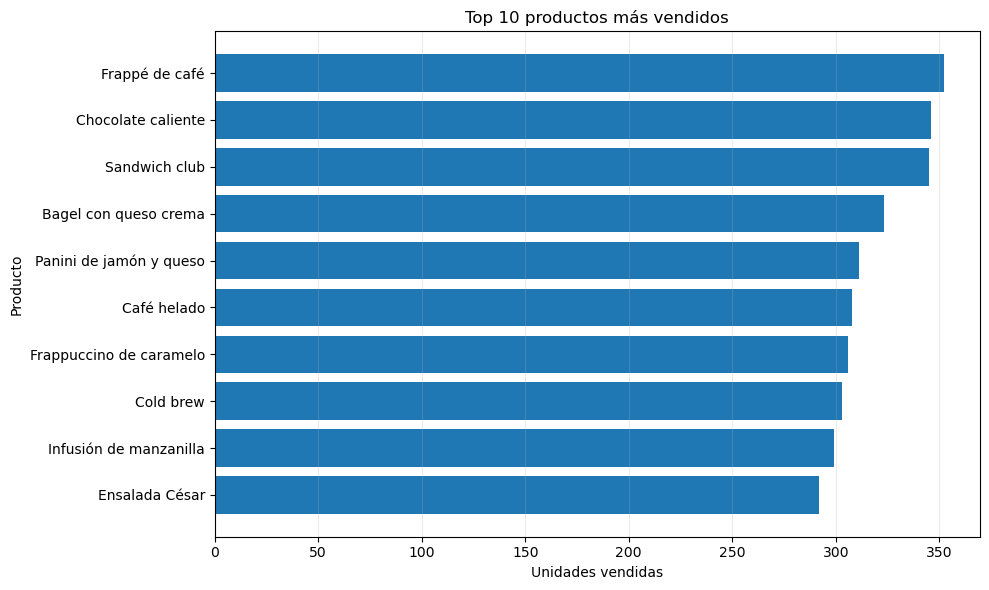

,unidades_vendidas
producto,
Frappé de café,352
Chocolate caliente,346
Sandwich club,345
Bagel con queso crema,323
Panini de jamón y queso,311
Café helado,308
Frappuccino de caramelo,306
Cold brew,303
Infusión de manzanilla,299


In [17]:
top_productos = (
    df.groupby('producto')['cantidad']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(top_productos.index, top_productos.values)
plt.title('Top 10 productos más vendidos')
plt.xlabel('Unidades vendidas')
plt.ylabel('Producto')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

top_productos.sort_values(ascending=False).to_frame('unidades_vendidas')


## Gráfica 6. Ingresos por categoría

La gráfica muestra que **Alimentos** es la categoría que genera mayores ingresos, con **88,484.63 MXN**, seguida de **Café frío con 64,312.74 MXN** y **Repostería con 56,620.12 MXN**. Esto indica que una categoría puede generar mayores ingresos aunque no sea la que tenga más unidades vendidas, debido a diferencias en los precios de los productos. Una posible explicación es que los alimentos tienen un mayor precio promedio. Con base en estos resultados, Café Cereza podría **fortalecer la oferta de las categorías con mayores ingresos y crear estrategias para aumentar las ventas de las categorías con menor aporte económico**.


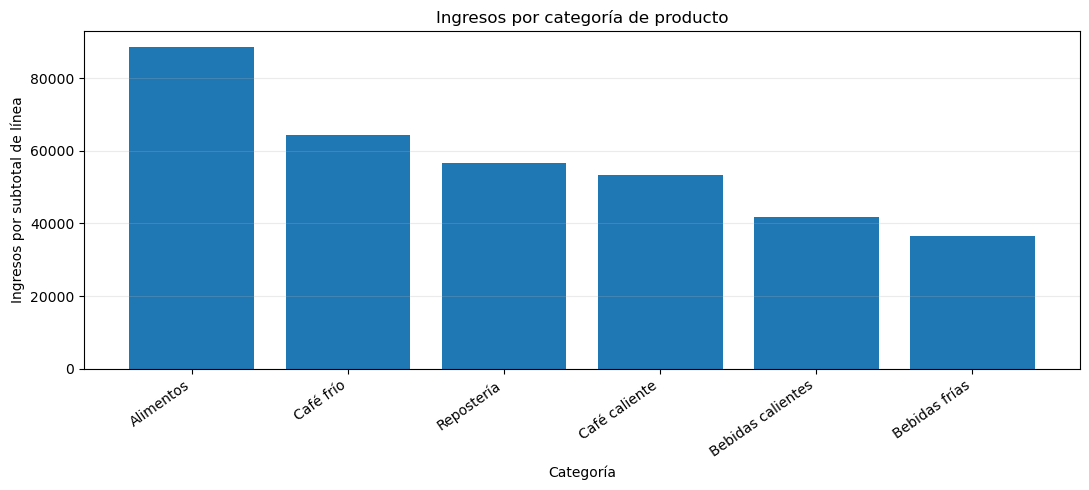

,ingresos
categoria_producto,
Alimentos,88484.63
Café frío,64312.74
Repostería,56620.12
Café caliente,53305.25
Bebidas calientes,41840.17
Bebidas frías,36496.61


In [18]:
ingresos_categoria = (
    df.groupby('categoria_producto')['subtotal_linea']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(11, 5))
plt.bar(ingresos_categoria.index, ingresos_categoria.values)
plt.title('Ingresos por categoría de producto')
plt.xlabel('Categoría')
plt.ylabel('Ingresos por subtotal de línea')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

ingresos_categoria.round(2).to_frame('ingresos')


## Gráfica 7. Ticket promedio por canal de venta

La gráfica muestra que la **Página web** tiene el ticket promedio más alto con **269.34 MXN**, seguida del canal **Presencial (mesero) con 262.39 MXN** y **Presencial (mostrador) con 251.43 MXN**. Esto indica que los clientes que compran mediante la página web tienden a realizar pedidos de mayor valor. Una posible explicación podría ser la facilidad para visualizar más productos al realizar el pedido en línea. Con base en estos resultados, Café Cereza podría **fortalecer el canal web mediante promociones, recomendaciones de productos y combos para incrementar las ventas**.


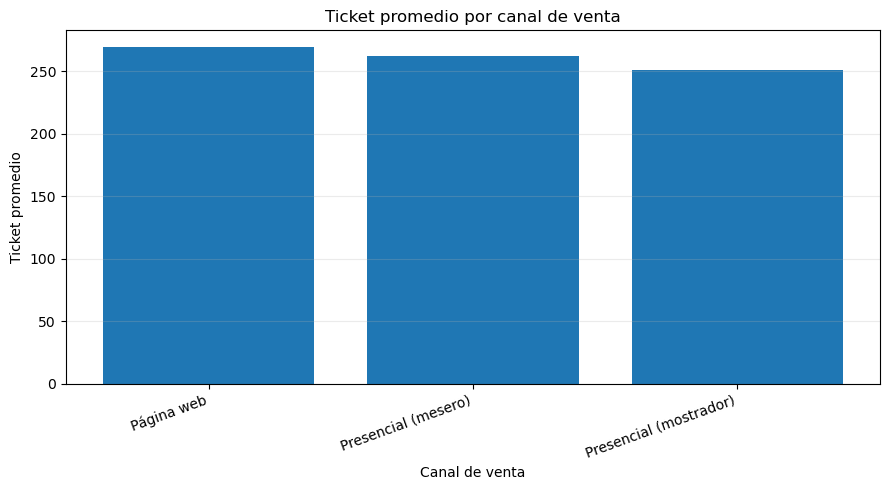

,ticket_promedio
canal_venta,
Página web,269.34
Presencial (mesero),262.39
Presencial (mostrador),251.43


In [19]:
ticket_canal = (
    pedidos_df.groupby('canal_venta')['total_pedido']
              .mean()
              .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(ticket_canal.index, ticket_canal.values)
plt.title('Ticket promedio por canal de venta')
plt.xlabel('Canal de venta')
plt.ylabel('Ticket promedio')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

ticket_canal.round(2).to_frame('ticket_promedio')


## Gráfica 8. Número de pedidos por tipo de cliente

La gráfica muestra que los **clientes frecuentes** concentran la mayor cantidad de pedidos, con **921**, seguidos por los clientes **VIP con 514**. En cambio, los clientes recurrentes registran **59 pedidos** y los nuevos solamente **6**. Esto indica que las ventas dependen principalmente de clientes que ya tienen una relación con Café Cereza. Una posible explicación es la fidelización de los clientes actuales. Con base en estos resultados, Café Cereza podría **mantener estrategias de fidelización y desarrollar promociones para atraer nuevos clientes**.


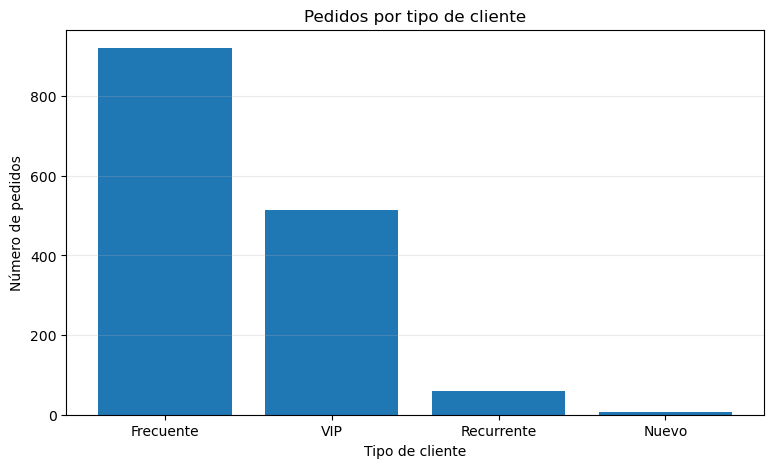

,pedidos
tipo_cliente,
Frecuente,921
VIP,514
Recurrente,59
Nuevo,6


In [20]:
pedidos_tipo_cliente = (
    pedidos_df['tipo_cliente']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(pedidos_tipo_cliente.index, pedidos_tipo_cliente.values)
plt.title('Pedidos por tipo de cliente')
plt.xlabel('Tipo de cliente')
plt.ylabel('Número de pedidos')
plt.grid(axis='y', alpha=0.25)
plt.show()

pedidos_tipo_cliente.to_frame('pedidos')


## Gráfica 9. Tiempo promedio de entrega por canal

La gráfica muestra que los tiempos promedio de entrega son **muy similares entre los tres canales de venta**. La **Página web** presenta el tiempo más alto con **26.78 minutos**, seguida de **Presencial (mesero) con 26.54 minutos** y **Presencial (mostrador) con 26.24 minutos**. Esto indica que el canal de venta no presenta grandes diferencias en los tiempos de entrega. Con base en estos resultados, Café Cereza podría **mantener sus procesos actuales y buscar mejoras generales que permitan reducir el tiempo de entrega en todos los canales**.


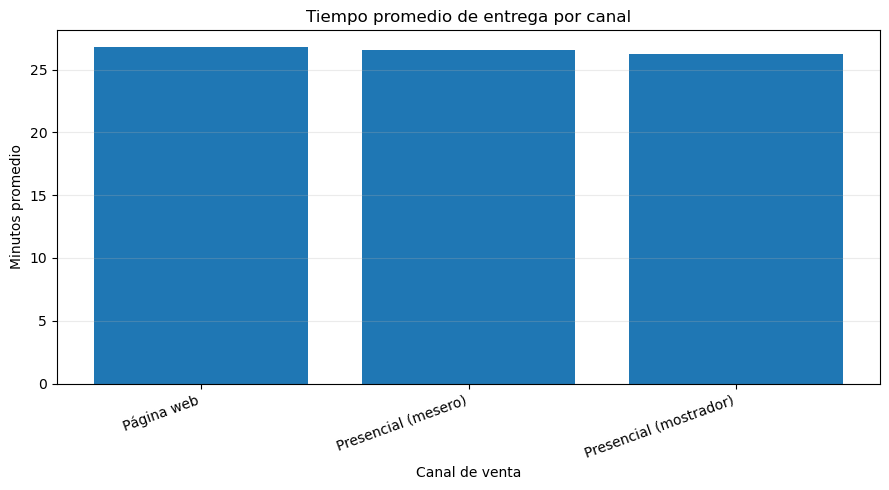

,minutos_promedio
canal_venta,
Página web,26.78
Presencial (mesero),26.54
Presencial (mostrador),26.24


In [21]:
tiempo_canal = (
    pedidos_df.groupby('canal_venta')['tiempo_entrega_min']
              .mean()
              .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(tiempo_canal.index, tiempo_canal.values)
plt.title('Tiempo promedio de entrega por canal')
plt.xlabel('Canal de venta')
plt.ylabel('Minutos promedio')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

tiempo_canal.round(2).to_frame('minutos_promedio')


## Gráfica 10. Reservaciones por estado

La gráfica muestra que la mayoría de las reservaciones fueron **completadas**, con **270 registros**, mientras que **39 fueron canceladas, 35 registraron no_show y 24 están pendientes**. Esto indica que gran parte de las reservaciones se concreta de manera satisfactoria. Una posible explicación es que los clientes que reservan tienen una intención clara de asistir. Con base en estos resultados, Café Cereza podría **mantener su proceso de reservaciones e implementar recordatorios para reducir las cancelaciones y los casos de no_show**.

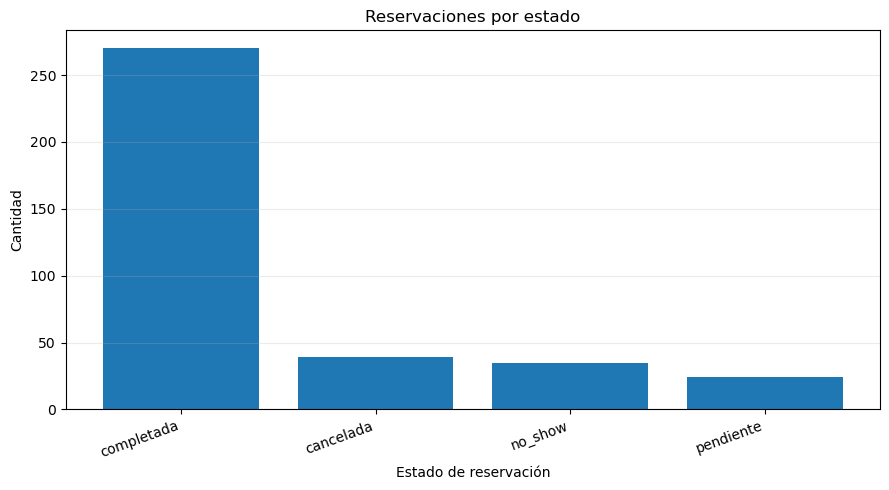

,reservaciones
estado_reservacion,
completada,270
cancelada,39
no_show,35
pendiente,24


In [22]:
reservas = (
    pedidos_df[pedidos_df['con_reservacion'] == True]
    ['estado_reservacion']
    .value_counts(dropna=False)
)

plt.figure(figsize=(9, 5))
plt.bar(reservas.index.astype(str), reservas.values)
plt.title('Reservaciones por estado')
plt.xlabel('Estado de reservación')
plt.ylabel('Cantidad')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

reservas.to_frame('reservaciones')


### 5.4 Análisis multivariado

En esta sección se analizan de manera conjunta **tres o más variables** para identificar patrones y relaciones más completas dentro de los datos. Esto permite comparar aspectos como **ventas, clientes, productos, canales y periodos de tiempo**, obteniendo una visión más amplia del comportamiento de Café Cereza.



## Gráfica 11. Ventas mensuales por canal

La gráfica muestra la evolución de los ingresos mensuales según el **canal de venta**. Los canales presenciales mantienen ingresos relativamente estables, mientras que la **Página web presenta un crecimiento notable**, especialmente durante 2026, alcanzando sus valores más altos en julio y agosto. Una posible explicación podría ser una mayor adopción del canal digital por parte de los clientes. Con base en estos resultados, Café Cereza podría **fortalecer su página web, mantener promociones digitales y asegurar la capacidad operativa para atender el crecimiento de los pedidos en línea**.


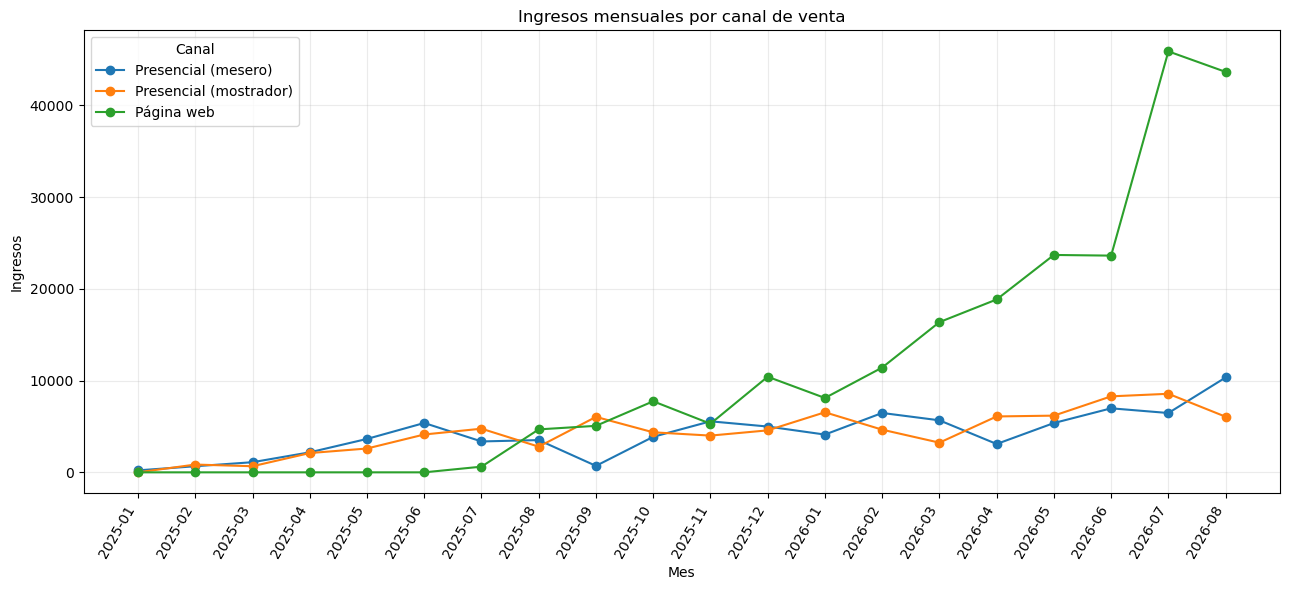

canal_venta,Presencial (mesero),Presencial (mostrador),Página web
periodo_mes,,,
2025-01,214.76,0.00,0.00
2025-02,664.30,846.99,0.00
2025-03,1104.13,666.15,0.00
2025-04,2181.37,2100.59,0.00
2025-05,3641.30,2597.61,0.00
2025-06,5379.36,4125.48,0.00
2025-07,3366.74,4757.60,618.50
2025-08,3516.01,2798.13,4681.76
2025-09,704.26,6043.38,5068.67


In [23]:
ingresos_mes_canal = (
    pedidos_df.groupby(['periodo_mes', 'canal_venta'])['total_pedido']
              .sum()
              .unstack(fill_value=0)
              .sort_index()
)

plt.figure(figsize=(13, 6))

for canal in ingresos_mes_canal.columns:
    plt.plot(
        ingresos_mes_canal.index,
        ingresos_mes_canal[canal],
        marker='o',
        label=canal
    )

plt.title('Ingresos mensuales por canal de venta')
plt.xlabel('Mes')
plt.ylabel('Ingresos')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Canal')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

ingresos_mes_canal.round(2)


## Gráfica 12. Unidades por categoría y canal

La gráfica muestra que la **Página web concentra la mayor cantidad de unidades vendidas en todas las categorías**, destacando **Repostería con 763 unidades**, seguida de **Alimentos con 737** y **Café caliente con 726**. Los canales presenciales presentan cantidades considerablemente menores. Una posible explicación es la mayor preferencia de los clientes por realizar pedidos en línea. Con base en estos resultados, Café Cereza podría **fortalecer el canal web y asegurar suficiente inventario de las categorías con mayor demanda digital**.

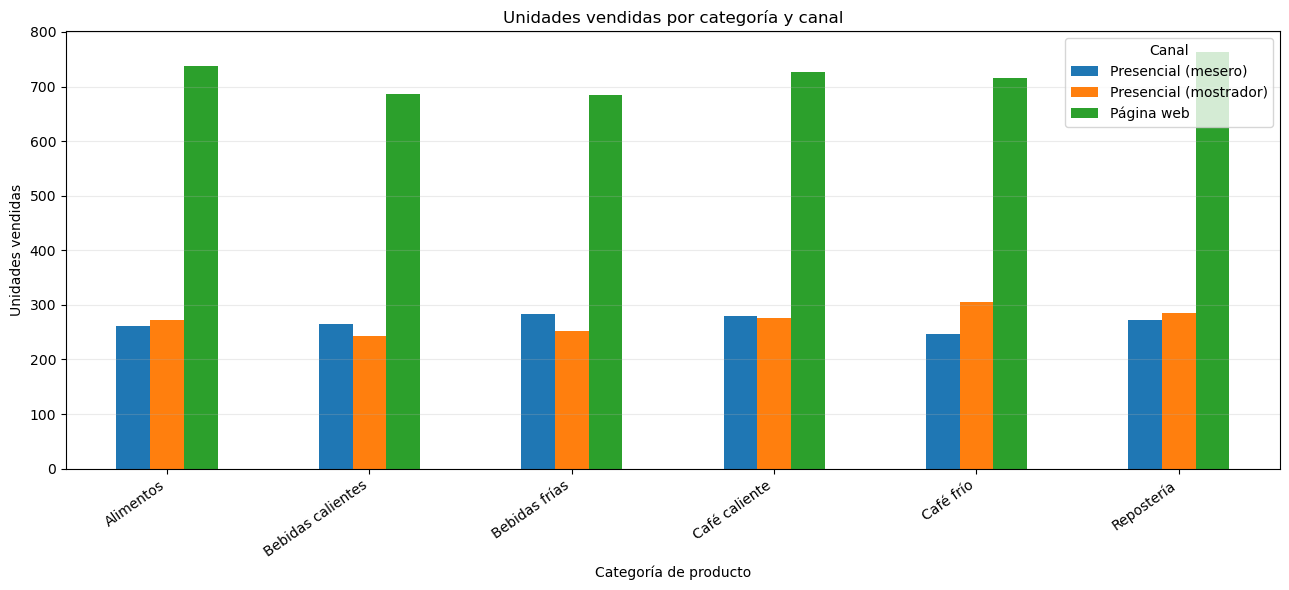

canal_venta,Presencial (mesero),Presencial (mostrador),Página web
categoria_producto,,,
Alimentos,262,272,737
Bebidas calientes,265,243,686
Bebidas frías,284,252,684
Café caliente,280,276,726
Café frío,247,306,716
Repostería,273,285,763


In [24]:
categoria_canal = (
    df.groupby(['categoria_producto', 'canal_venta'])['cantidad']
      .sum()
      .unstack(fill_value=0)
)

categoria_canal.plot(kind='bar', figsize=(13, 6))
plt.title('Unidades vendidas por categoría y canal')
plt.xlabel('Categoría de producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Canal')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

categoria_canal


## Gráfica 13. Ticket promedio por canal y tipo de cliente


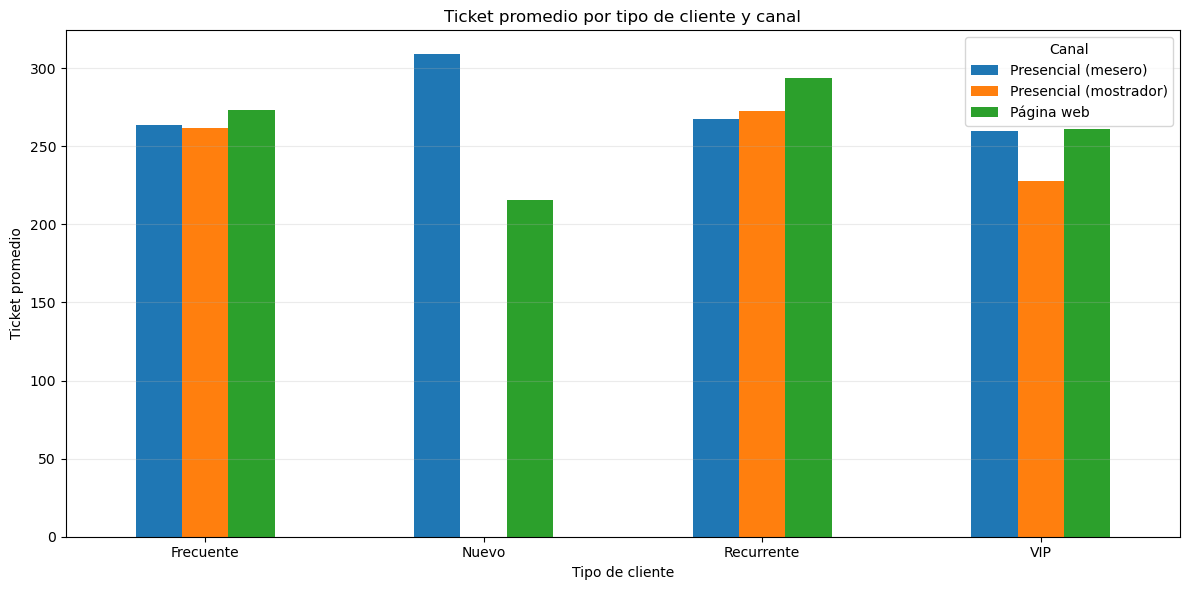

canal_venta,Presencial (mesero),Presencial (mostrador),Página web
tipo_cliente,,,
Frecuente,263.36,261.58,273.10
Nuevo,308.75,NaN,215.30
Recurrente,267.65,272.82,293.60
VIP,259.60,227.90,261.19


In [25]:
ticket_canal_cliente = (
    pedidos_df.groupby(['tipo_cliente', 'canal_venta'])['total_pedido']
              .mean()
              .unstack()
)

ticket_canal_cliente.plot(kind='bar', figsize=(12, 6))
plt.title('Ticket promedio por tipo de cliente y canal')
plt.xlabel('Tipo de cliente')
plt.ylabel('Ticket promedio')
plt.xticks(rotation=0)
plt.legend(title='Canal')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

ticket_canal_cliente.round(2)


### 5.5 Análisis temporal

En esta sección se analiza el comportamiento de los datos **a lo largo del tiempo**, con el objetivo de identificar tendencias, variaciones y periodos de mayor o menor actividad. Esto permite conocer cómo evolucionan las **ventas y pedidos de Café Cereza** según el mes, día u hora.

## Gráfica 14. Tendencia mensual de ingresos

La gráfica muestra una **tendencia general de crecimiento en los ingresos mensuales**, pasando de **214.76 MXN en enero de 2025** a más de **60,000 MXN en julio y agosto de 2026**. Aunque existen algunas disminuciones entre meses, el crecimiento se vuelve más notable durante 2026. Una posible explicación podría ser el aumento progresivo de pedidos y el crecimiento del canal web. Con base en estos resultados, Café Cereza podría **preparar inventario, personal y estrategias de venta para responder a los periodos de mayor crecimiento**.


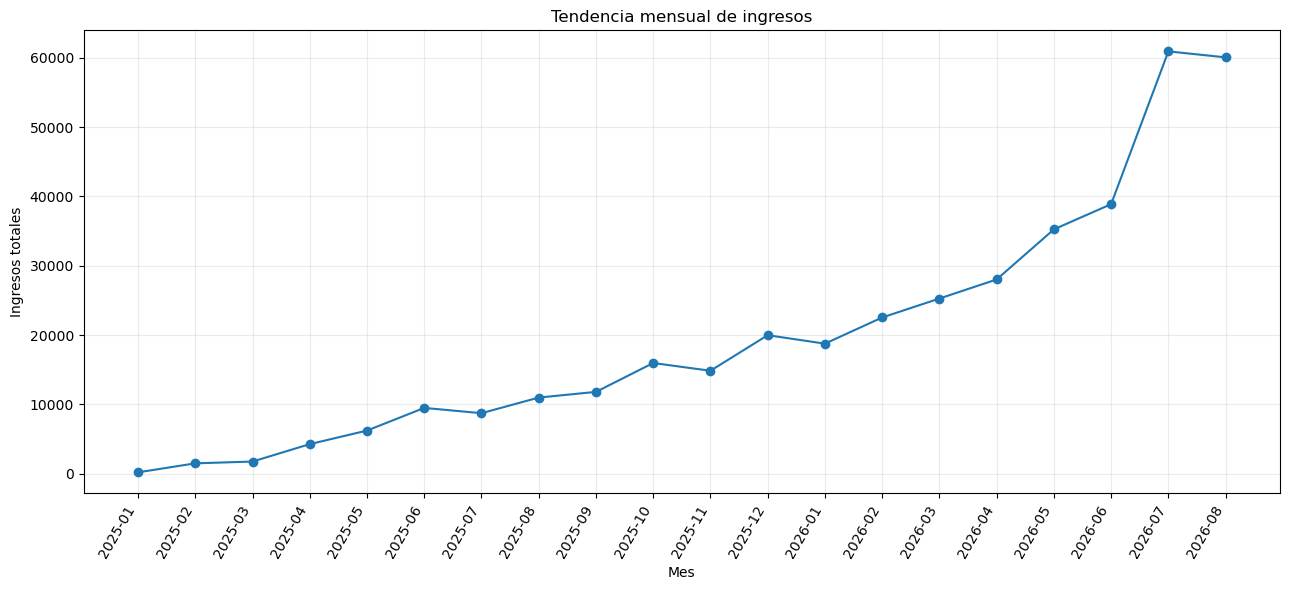

,ingresos
periodo_mes,
2025-01,214.76
2025-02,1511.29
2025-03,1770.28
2025-04,4281.96
2025-05,6238.91
2025-06,9504.84
2025-07,8742.84
2025-08,10995.90
2025-09,11816.31


In [26]:
ingresos_mensuales = (
    pedidos_df.groupby('periodo_mes')['total_pedido']
              .sum()
              .sort_index()
)

plt.figure(figsize=(13, 6))
plt.plot(ingresos_mensuales.index, ingresos_mensuales.values, marker='o')
plt.title('Tendencia mensual de ingresos')
plt.xlabel('Mes')
plt.ylabel('Ingresos totales')
plt.xticks(rotation=60, ha='right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

ingresos_mensuales.round(2).to_frame('ingresos')


## Gráfica 15. Comparación mensual 2025 vs 2026

La gráfica muestra que, entre **enero y agosto**, los ingresos de **2026 son considerablemente mayores que los registrados en los mismos meses de 2025**, destacando julio y agosto con más de **60,000 MXN**. Esto refleja un crecimiento importante de los ingresos entre ambos años. Una posible explicación podría ser el aumento en la cantidad de pedidos y una mayor actividad comercial. Con base en estos resultados, Café Cereza podría **analizar qué factores impulsaron este crecimiento para mantenerlos y fortalecerlos en los próximos meses**.

> **Nota:** La comparación se realiza únicamente de **enero a agosto**, ya que los valores en cero de septiembre a diciembre de 2026 corresponden a meses que todavía no cuentan con registros y no deben interpretarse como ausencia de ventas.


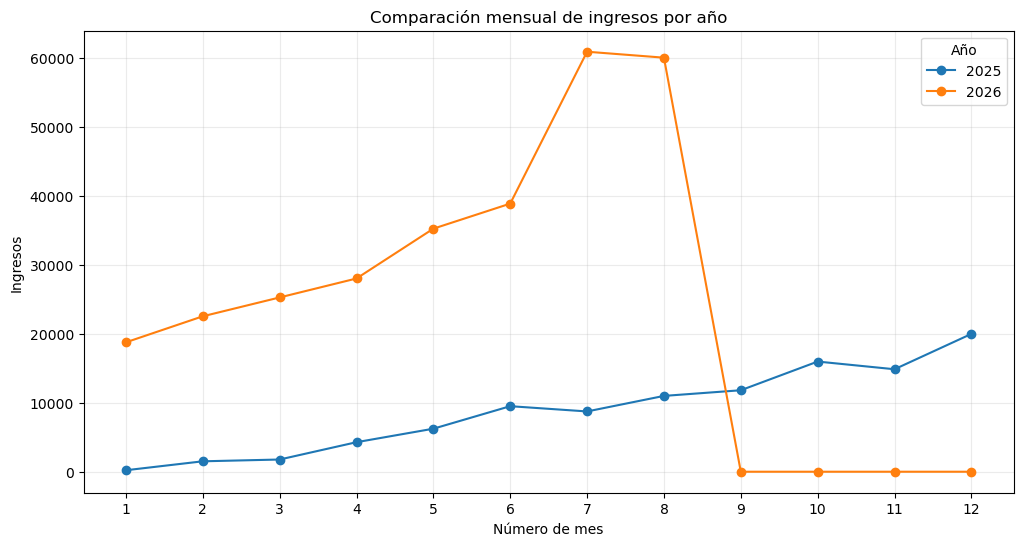

anio,2025,2026
mes_num,,
1,214.76,18769.16
2,1511.29,22543.48
3,1770.28,25277.60
4,4281.96,28026.59
5,6238.91,35251.02
6,9504.84,38885.27
7,8742.84,60914.98
8,10995.90,60051.96
9,11816.31,0.00


In [27]:
comparacion_anual = (
    pedidos_df.groupby(['mes_num', 'anio'])['total_pedido']
              .sum()
              .unstack(fill_value=0)
              .sort_index()
)

plt.figure(figsize=(12, 6))

for anio in comparacion_anual.columns:
    plt.plot(
        comparacion_anual.index,
        comparacion_anual[anio],
        marker='o',
        label=str(anio)
    )

plt.title('Comparación mensual de ingresos por año')
plt.xlabel('Número de mes')
plt.ylabel('Ingresos')
plt.xticks(range(1, 13))
plt.legend(title='Año')
plt.grid(alpha=0.25)
plt.show()

comparacion_anual.round(2)


## Gráfica 16. Pedidos por hora del día

La gráfica muestra que los pedidos se mantienen **relativamente distribuidos durante todo el horario**, aunque existen algunos periodos de mayor actividad. La mayor cantidad se registra a las **11:00 horas con 126 pedidos**, seguida de las **13:00 horas con 122** y las **18:00 horas con 116**. Una posible explicación podría estar relacionada con horarios habituales de desayuno, comida y salida de actividades. Con base en estos resultados, Café Cereza podría **reforzar el personal y la preparación de productos durante las horas de mayor demanda**.


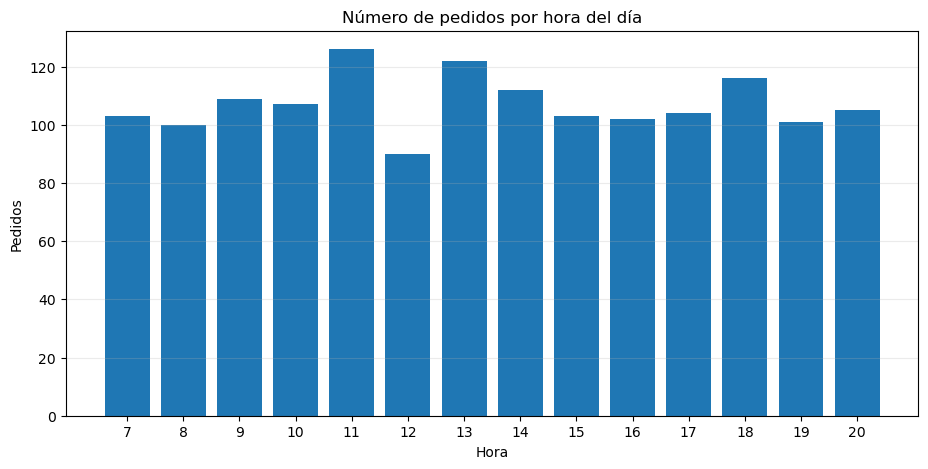

,pedidos
hora,
7,103
8,100
9,109
10,107
11,126
12,90
13,122
14,112
15,103


In [28]:
pedidos_hora = (
    pedidos_df.groupby('hora')['id_pedido']
              .nunique()
              .sort_index()
)

plt.figure(figsize=(11, 5))
plt.bar(pedidos_hora.index.astype(int), pedidos_hora.values)
plt.title('Número de pedidos por hora del día')
plt.xlabel('Hora')
plt.ylabel('Pedidos')
plt.xticks(sorted(pedidos_hora.index.astype(int).unique()))
plt.grid(axis='y', alpha=0.25)
plt.show()

pedidos_hora.to_frame('pedidos')


### Gráfica 17. Pedidos por día de la semana

La gráfica muestra que los pedidos se mantienen **relativamente equilibrados durante la semana**, aunque el **martes registra la mayor cantidad con 236 pedidos**, mientras que el **domingo presenta la menor con 194**. Una posible explicación podría estar relacionada con diferencias en los hábitos de consumo de los clientes según el día. Con base en estos resultados, Café Cereza podría **ajustar el personal e inventario de acuerdo con la demanda de cada día y aplicar promociones en los días con menor actividad**.

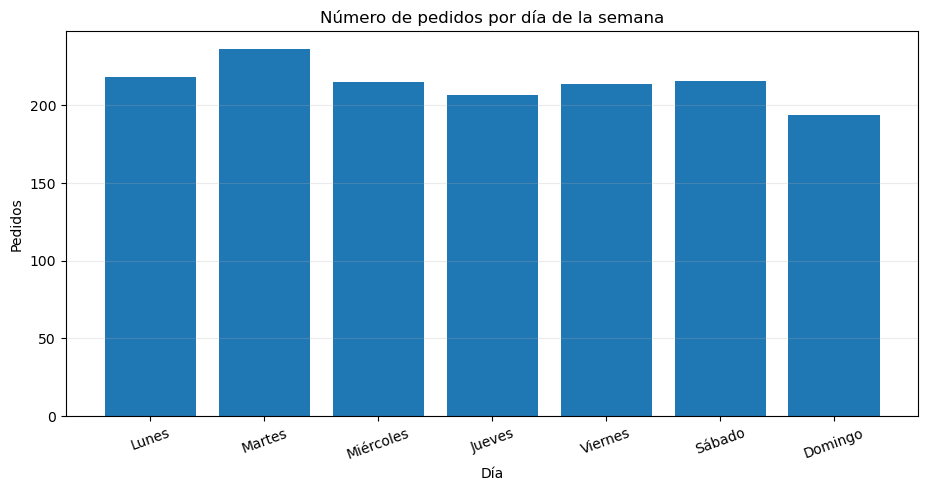

,pedidos
dia_semana,
Lunes,218
Martes,236
Miércoles,215
Jueves,207
Viernes,214
Sábado,216
Domingo,194


In [29]:
orden_dias_es = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

pedidos_dia = (
    pedidos_df['dia_semana']
    .value_counts()
    .reindex(orden_dias_es)
)

plt.figure(figsize=(11, 5))
plt.bar(pedidos_dia.index, pedidos_dia.values)
plt.title('Número de pedidos por día de la semana')
plt.xlabel('Día')
plt.ylabel('Pedidos')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.25)
plt.show()

pedidos_dia.to_frame('pedidos')


### Gráfica 18. Participación mensual del canal web

La gráfica muestra que la participación del canal web comienza en **julio de 2025 con 11.76 %** y presenta una tendencia general de crecimiento, alcanzando su punto más alto en **julio de 2026 con 71.81 %**. Esto indica que la página web adquirió cada vez mayor importancia como canal para realizar pedidos. Una posible explicación podría ser una mayor adopción y familiaridad de los clientes con el canal digital. Con base en estos resultados, Café Cereza podría **continuar fortaleciendo la página web y mejorar la experiencia de compra para mantener el crecimiento del canal digital**.


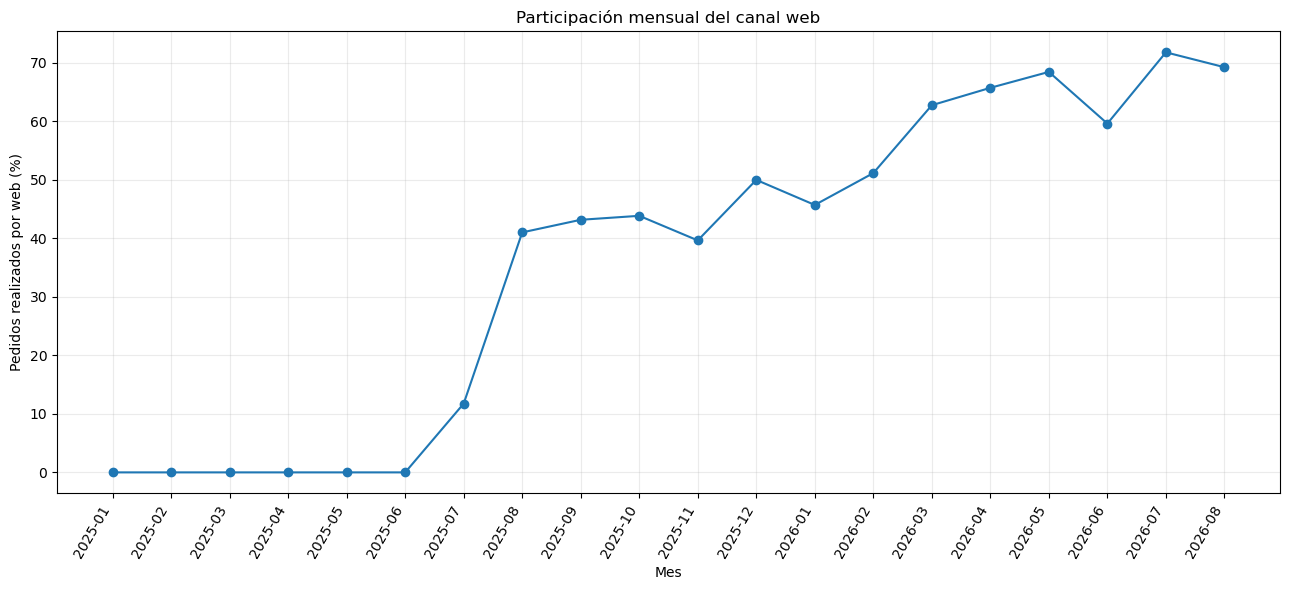

,participacion_web_pct
periodo_mes,
2025-01,0.00
2025-02,0.00
2025-03,0.00
2025-04,0.00
2025-05,0.00
2025-06,0.00
2025-07,11.76
2025-08,41.03
2025-09,43.18


In [30]:
participacion_web = (
    pedidos_df.assign(es_web=pedidos_df['canal_venta'].eq('Página web').astype(int))
              .groupby('periodo_mes')['es_web']
              .mean()
              .mul(100)
              .sort_index()
)

plt.figure(figsize=(13, 6))
plt.plot(participacion_web.index, participacion_web.values, marker='o')
plt.title('Participación mensual del canal web')
plt.xlabel('Mes')
plt.ylabel('Pedidos realizados por web (%)')
plt.xticks(rotation=60, ha='right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

participacion_web.round(2).to_frame('participacion_web_pct')


### Gráfica 19. Pedidos antes y después del lanzamiento web

La gráfica muestra un aumento importante en el número de pedidos después del lanzamiento de la página web. En este periodo se registraron **837 pedidos por web**, además de **302 en mostrador y 272 con mesero**. Esto indica que el canal web adquirió una participación relevante dentro de las ventas. Una posible explicación podría ser la facilidad de realizar pedidos de manera digital. Con base en estos resultados, Café Cereza podría **seguir impulsando el canal web y utilizarlo como complemento de la atención presencial**.

> **Nota:** Los periodos comparados tienen distinta duración, por lo que el aumento total de pedidos no debe atribuirse únicamente al lanzamiento de la página web.


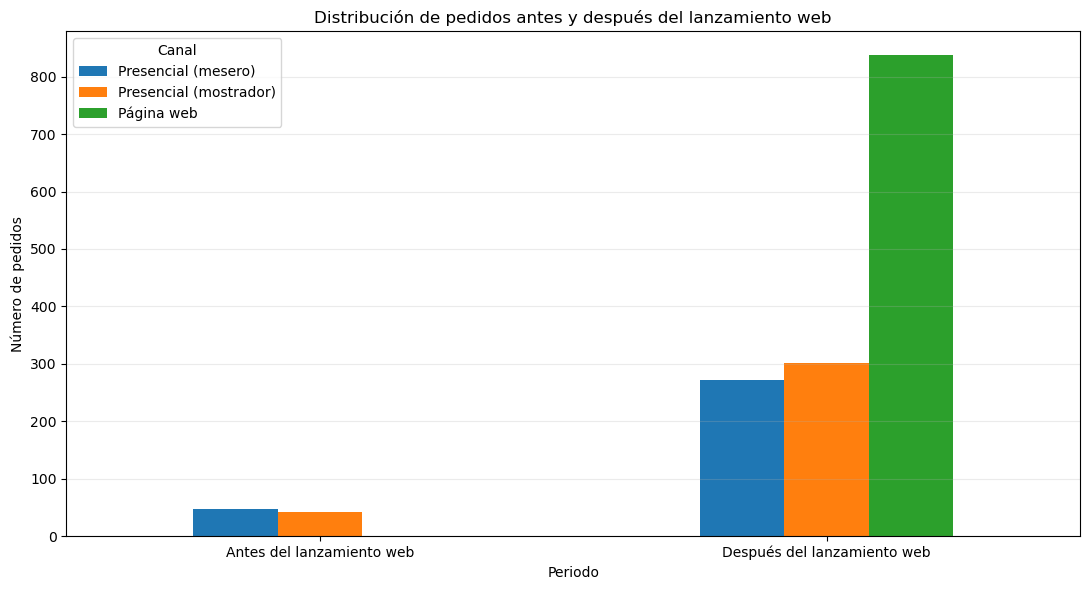

canal_venta,Presencial (mesero),Presencial (mostrador),Página web
periodo_web,,,
Antes del lanzamiento web,47,42,0
Después del lanzamiento web,272,302,837


In [31]:
fecha_lanzamiento_web = pd.Timestamp('2025-07-01')

pedidos_df['periodo_web'] = np.where(
    pedidos_df['fecha_pedido'] < fecha_lanzamiento_web,
    'Antes del lanzamiento web',
    'Después del lanzamiento web'
)

resumen_web = (
    pedidos_df.groupby(['periodo_web', 'canal_venta'])['id_pedido']
              .nunique()
              .unstack(fill_value=0)
)

resumen_web.plot(kind='bar', figsize=(11, 6))
plt.title('Distribución de pedidos antes y después del lanzamiento web')
plt.xlabel('Periodo')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=0)
plt.legend(title='Canal')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

resumen_web


### 5.6 Correlación entre variables numéricas

En esta sección se analiza la **relación estadística entre las variables numéricas** del dataset para identificar si tienden a aumentar o disminuir de manera conjunta. Los valores de correlación permiten reconocer relaciones **positivas, negativas o débiles** entre las variables. Es importante considerar que una correlación representa únicamente una **asociación estadística y no demuestra que una variable sea la causa de otra**.

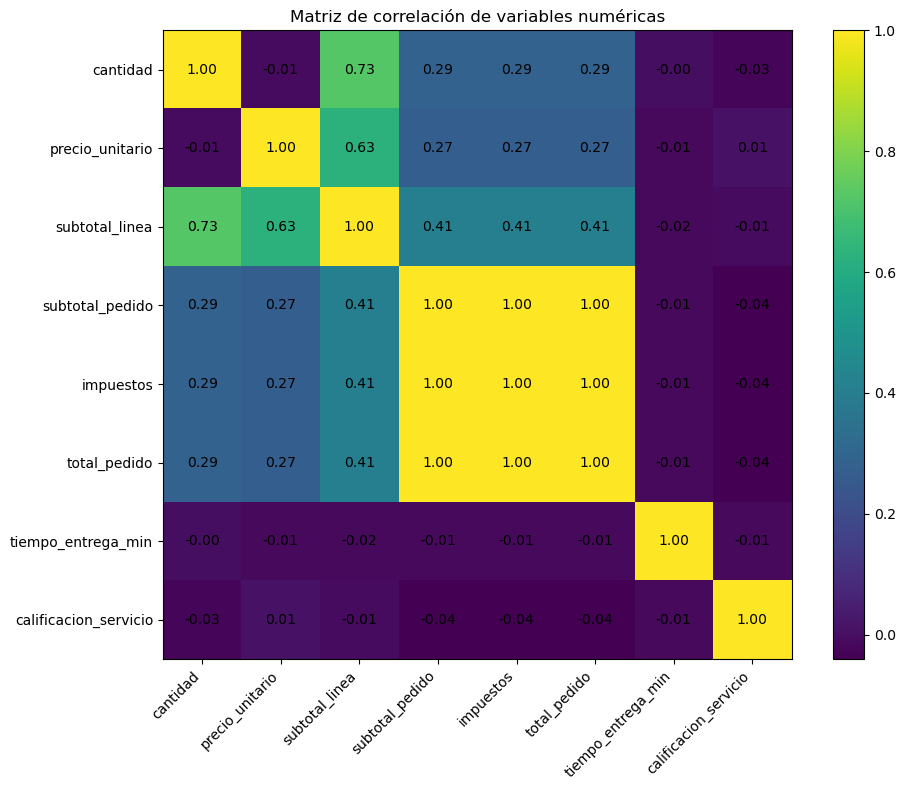

,cantidad,precio_unitario,subtotal_linea,subtotal_pedido,impuestos,total_pedido,tiempo_entrega_min,calificacion_servicio
cantidad,1.00,-0.01,0.73,0.29,0.29,0.29,-0.00,-0.03
precio_unitario,-0.01,1.00,0.63,0.27,0.27,0.27,-0.01,0.01
subtotal_linea,0.73,0.63,1.00,0.41,0.41,0.41,-0.02,-0.01
subtotal_pedido,0.29,0.27,0.41,1.00,1.00,1.00,-0.01,-0.04
impuestos,0.29,0.27,0.41,1.00,1.00,1.00,-0.01,-0.04
total_pedido,0.29,0.27,0.41,1.00,1.00,1.00,-0.01,-0.04
tiempo_entrega_min,-0.00,-0.01,-0.02,-0.01,-0.01,-0.01,1.00,-0.01
calificacion_servicio,-0.03,0.01,-0.01,-0.04,-0.04,-0.04,-0.01,1.00


In [32]:
columnas_correlacion = [
    'cantidad',
    'precio_unitario',
    'subtotal_linea',
    'subtotal_pedido',
    'impuestos',
    'total_pedido',
    'tiempo_entrega_min',
    'calificacion_servicio'
]

corr = df[columnas_correlacion].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

plt.title('Matriz de correlación de variables numéricas')
plt.colorbar(im)
plt.tight_layout()
plt.show()

corr.round(2)


# Hallazgos automáticos

Los resultados obtenidos resumen los principales patrones identificados durante el análisis exploratorio. El **Frappé de café** destaca como el producto con más unidades vendidas, mientras que **Repostería** es la categoría con mayor volumen de ventas. La **Página web** presenta el ticket promedio más alto con **269.34 MXN**, y la mayor actividad de pedidos se registra a las **11:00 horas** y los **martes**.

Además, **julio de 2026** fue el mes con mayores ingresos, alcanzando **60,914.98 MXN**. Por otro lado, se obtuvo una **tasa de cancelación de pedidos del 5.33 %** y una **tasa de no_show en reservaciones del 9.51 %**. Estos hallazgos permiten identificar áreas relevantes para la planificación de inventario, personal, estrategias de venta y mejora de las reservaciones.


In [33]:
# Principales resultados
producto_top = df.groupby('producto')['cantidad'].sum().idxmax()
producto_top_unidades = df.groupby('producto')['cantidad'].sum().max()

categoria_top = df.groupby('categoria_producto')['cantidad'].sum().idxmax()
categoria_top_unidades = df.groupby('categoria_producto')['cantidad'].sum().max()

canal_ticket_top = pedidos_df.groupby('canal_venta')['total_pedido'].mean().idxmax()
canal_ticket_valor = pedidos_df.groupby('canal_venta')['total_pedido'].mean().max()

hora_pico = pedidos_df.groupby('hora')['id_pedido'].nunique().idxmax()
pedidos_hora_pico = pedidos_df.groupby('hora')['id_pedido'].nunique().max()

dia_pico = pedidos_df['dia_semana'].value_counts().idxmax()
pedidos_dia_pico = pedidos_df['dia_semana'].value_counts().max()

mes_top = pedidos_df.groupby('periodo_mes')['total_pedido'].sum().idxmax()
mes_top_ingresos = pedidos_df.groupby('periodo_mes')['total_pedido'].sum().max()

cancelacion = (
    pedidos_df['estado_pedido'].eq('cancelado').mean() * 100
)

reservas_df = pedidos_df[pedidos_df['con_reservacion'] == True].copy()
if len(reservas_df) > 0:
    tasa_no_show = reservas_df['estado_reservacion'].eq('no_show').mean() * 100
else:
    tasa_no_show = np.nan

hallazgos = pd.DataFrame({
    'Indicador': [
        'Producto con más unidades vendidas',
        'Categoría con más unidades vendidas',
        'Canal con mayor ticket promedio',
        'Hora con más pedidos',
        'Día con más pedidos',
        'Mes con mayores ingresos',
        'Tasa de cancelación de pedidos',
        'Tasa de no_show en reservaciones'
    ],
    'Resultado': [
        f'{producto_top} ({producto_top_unidades:.0f} unidades)',
        f'{categoria_top} ({categoria_top_unidades:.0f} unidades)',
        f'{canal_ticket_top} (${canal_ticket_valor:,.2f})',
        f'{int(hora_pico):02d}:00 ({pedidos_hora_pico} pedidos)',
        f'{dia_pico} ({pedidos_dia_pico} pedidos)',
        f'{mes_top} (${mes_top_ingresos:,.2f})',
        f'{cancelacion:.2f}%',
        f'{tasa_no_show:.2f}%' if pd.notna(tasa_no_show) else 'No disponible'
    ]
})

hallazgos


,Indicador,Resultado
0,Producto con más unidades vendidas,Frappé de café (352 unidades)
1,Categoría con más unidades vendidas,Repostería (1321 unidades)
2,Canal con mayor ticket promedio,Página web ($269.34)
3,Hora con más pedidos,11:00 (126 pedidos)
4,Día con más pedidos,Martes (236 pedidos)
5,Mes con mayores ingresos,"2026-07 ($60,914.98)"
6,Tasa de cancelación de pedidos,5.33%
7,Tasa de no_show en reservaciones,9.51%


# Relación entre preguntas de negocio y resultados

Esta sección relaciona las **preguntas de negocio planteadas con los análisis realizados**, permitiendo identificar qué resultados y gráficas proporcionan evidencia para responder cada una. De esta manera, se facilita la conexión entre los datos obtenidos y las necesidades de Café Cereza, considerando aspectos como **demanda por día y hora, productos más vendidos, ticket promedio por canal, cancelaciones, reservaciones y evolución del canal web**.

Esta relación permite comprobar que cada pregunta de negocio cuenta con un análisis específico que respalda los hallazgos obtenidos durante el EDA.


In [34]:
relacion_preguntas = pd.DataFrame({
    'Pregunta de negocio': [
        '¿Qué días y horarios presentan mayor demanda?',
        '¿Qué productos presentan mayor demanda?',
        '¿Qué canal presenta mayor ticket promedio?',
        '¿Cómo se comportan las cancelaciones de pedidos?',
        '¿Cómo se comporta la no asistencia en reservaciones?',
        '¿Cómo cambia la participación del canal web a través del tiempo?'
    ],
    'Análisis utilizado': [
        'Pedidos por día y hora',
        'Unidades vendidas por producto',
        'Ticket promedio por canal',
        'Estado de pedido',
        'Estado de reservación',
        'Participación mensual del canal web'
    ],
    'Gráfica relacionada': [
        'Gráficas 16 y 17',
        'Gráfica 5',
        'Gráfica 7',
        'Hallazgos automáticos',
        'Gráfica 10',
        'Gráfica 18'
    ]
})

relacion_preguntas


,Pregunta de negocio,Análisis utilizado,Gráfica relacionada
0,¿Qué días y horarios presentan mayor demanda?,Pedidos por día y hora,Gráficas 16 y 17
1,¿Qué productos presentan mayor demanda?,Unidades vendidas por producto,Gráfica 5
2,¿Qué canal presenta mayor ticket promedio?,Ticket promedio por canal,Gráfica 7
3,¿Cómo se comportan las cancelaciones de pedidos?,Estado de pedido,Hallazgos automáticos
4,¿Cómo se comporta la no asistencia en reservac...,Estado de reservación,Gráfica 10
5,¿Cómo cambia la participación del canal web a ...,Participación mensual del canal web,Gráfica 18



# Observaciones metodológicas importantes

Para garantizar resultados correctos, el análisis utiliza **`pedidos_df` para ingresos y ticket promedio**, evitando duplicar el valor de un mismo pedido, mientras que **`df` se utiliza para analizar productos y categorías** a nivel de detalle.

Además, los resultados se interpretan únicamente con las variables disponibles en el dataset, por lo que **no se realizan conclusiones sobre costos, utilidad, dispositivos o campañas publicitarias**. También debe considerarse que **2026 contiene información únicamente hasta agosto**, por lo que no representa un año completo. Finalmente, las relaciones encontradas mediante correlación se interpretan como **asociaciones estadísticas y no como relaciones de causa y efecto**.


# Conclusión

El análisis exploratorio de datos permitió identificar los principales patrones relacionados con las **ventas, productos, clientes, canales y reservaciones de Café Cereza**. Los resultados muestran una tendencia general de crecimiento en los ingresos, destacando **julio de 2026 con 60,914.98 MXN**, así como una participación cada vez mayor de la **página web**, que además presenta el ticket promedio más alto con **269.34 MXN**.

En cuanto a la demanda, el **Frappé de café** fue el producto con más unidades vendidas y **Repostería** la categoría con mayor volumen. También se identificó que los **martes** y las **11:00 horas** presentan la mayor cantidad de pedidos, información que puede apoyar la planificación de personal e inventario. Por otra parte, la mayoría de las reservaciones se completan correctamente, aunque existen oportunidades para reducir las cancelaciones y la no asistencia.

En conjunto, estos resultados proporcionan información útil para que Café Cereza pueda **fortalecer su canal digital, mejorar la planificación operativa, mantener disponibles los productos de mayor demanda y desarrollar estrategias orientadas a mejorar la experiencia y fidelización de sus clientes**. Los hallazgos deben interpretarse considerando las características y limitaciones del dataset, especialmente que los datos de **2026 abarcan únicamente hasta agosto** y que las asociaciones identificadas no implican necesariamente causalidad.